## 0. Введение

Этот ноутбук демонстрирует использование `manuscript-ocr` совместно с внешним детектором текста на базе YOLO в версии `0.1.12` и выше. В примере показано, как заменить стандартный детектор в `Pipeline` на внешнюю модель `Daniil-Domino/yolo11x-text-detection`, обернув ее в класс `YoloDetector`, совместимый с API библиотеки.

Модель `Daniil-Domino/yolo11x-text-detection` используется здесь как внешний компонент. Она не является частью репозитория `manuscript-ocr`, не входит в поставку проекта и не распространяется вместе с ним. Библиотека `ultralytics`, необходимая для загрузки и запуска этой модели, также не входит в базовые зависимости проекта и устанавливается отдельно для данного примера.

## 1. Установка зависимостей

In [ ]:
%pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 46.1 MB/s eta 0:00:00


In [ ]:
%pip install "manuscript-ocr>=0.1.12"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 574.2/574.2 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 98.3 MB/s eta 0:00:00


## 2. Определение детектора, совместимого с YOLO

## Определение детектора, совместимого с YOLO

Согласно документации для версии `0.1.12` и выше, детектор в `Pipeline` должен реализовать метод `predict`, который принимает изображение и возвращает объект `Page` с результатами детекции.

В общем виде интерфейс детектора выглядит так:

`predict(self, image, **kwargs) -> Page`

В данном примере класс `YoloDetector` использует внешнюю YOLO-модель для поиска текстовых областей, после чего преобразует найденные области в объект `Page`, совместимый с API библиотеки `manuscript-ocr`.

In [3]:
from pathlib import Path
from typing import Optional, Union

import numpy as np
from ultralytics import YOLO

from manuscript.data import Block, Line, Page, TextSpan
from manuscript.utils import organize_page, read_image


class YoloDetector:
    def __init__(
        self,
        weights: Union[str, Path],
        conf: float = 0.25,
        iou: float = 0.7,
        imgsz: int = 640,
        device: Optional[str] = None,
        sort_reading_order: bool = True,
        split_into_columns: bool = True,
        max_columns: int = 10,
    ):
        self.conf = conf
        self.iou = iou
        self.imgsz = imgsz
        self.sort_reading_order = sort_reading_order
        self.split_into_columns = split_into_columns
        self.max_columns = max_columns

        self.model = YOLO(str(weights))
        if device:
            self.model.to(device)

        self.last_raw_result = None

    def predict(self, image: Union[str, Path, np.ndarray], **kwargs) -> Page:
        image_array = read_image(image)

        result = self.model.predict(
            image_array,
            conf=self.conf,
            iou=self.iou,
            imgsz=self.imgsz,
            verbose=False,
        )[0]
        self.last_raw_result = result

        boxes = result.boxes.data.tolist() if result.boxes is not None else []
        text_spans = [
            TextSpan(
                polygon=[(x1, y1), (x2, y1), (x2, y2), (x1, y2)],
                detection_confidence=float(conf),
            )
            for x1, y1, x2, y2, conf, _ in boxes
        ]

        page = Page(
            blocks=[Block(lines=[Line(text_spans=text_spans, order=0)], order=0)]
        )

        if self.sort_reading_order and text_spans:
            return organize_page(
                page,
                max_splits=self.max_columns,
                use_columns=self.split_into_columns,
            )

        for i, span in enumerate(text_spans):
            span.order = i

        return page

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## 3. Пример использования кастомного детектора

[TRBA] Device configuration:
  Requested device: cpu
  Requested providers: ['CPUExecutionProvider']
  Active providers: ['CPUExecutionProvider']
  Running on: CPUExecutionProvider
[CharLM] Device configuration:
  Requested device: cpu
  Requested providers: ['CPUExecutionProvider']
  Active providers: ['CPUExecutionProvider']
  Running on: CPUExecutionProvider
{'page': Page(blocks=[Block(lines=[Line(text_spans=[TextSpan(polygon=[(348.1646728515625, 246.70977783203125), (538.0136108398438, 246.70977783203125), (538.0136108398438, 281.8098449707031), (348.1646728515625, 281.8098449707031)], detection_confidence=0.6472296714782715, text='хозяйства,', recognition_confidence=0.9986688494682312, order=0), TextSpan(polygon=[(556.547119140625, 252.9371337890625), (687.4335327148438, 252.9371337890625), (687.4335327148438, 279.0398864746094), (556.547119140625, 279.0398864746094)], detection_confidence=0.3993249535560608, text='ничѣмъ', recognition_confidence=0.9990975260734558, order=1), Text

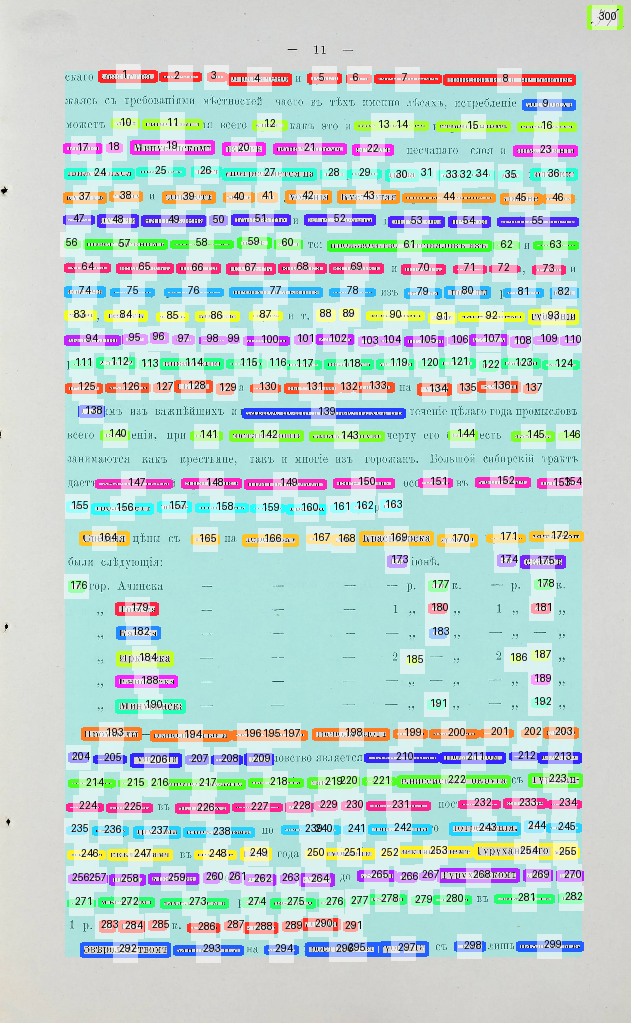

In [ ]:
from pathlib import Path
from urllib.request import urlretrieve

from huggingface_hub import hf_hub_download

from manuscript import Pipeline
from manuscript.utils.visualization import visualize_page
from manuscript.recognizers import TRBA
from manuscript.correctors import CharLM

# Скачиваем модель детектора с Hugging Face Hub
model_path = hf_hub_download(
    repo_id="Daniil-Domino/yolo11x-text-detection",
    filename="model.pt"
)

# Скачиваем пример изображения из основного репозитория
image_url = "https://raw.githubusercontent.com/konstantinkozhin/manuscript-ocr/main/example/images/img2.jpeg"
image_path = Path("img2.jpeg")

if not image_path.exists():
    urlretrieve(image_url, image_path)

pipeline = Pipeline(
    detector=YoloDetector(
        weights=model_path,
        conf=0.25,
    ),  # Детектор Daniil-Domino/yolo11x-text-detection, совместимый с manuscript благодаря классу-обёртке YoloDetector
    recognizer=TRBA(weights="trba_lite_g1"),  # Внутренняя модель для распознавания текста
    corrector=CharLM(weights="modern_charlm_g1"),  # Внутренняя модель для корректировки распознанного текста
)

# Запуск пайплайна
result = pipeline.predict(str(image_path))

# Весь объект результата
print(result)

# Текст
text = pipeline.get_text(result["page"])
print(text)

# Визуализация
visualize_page(
    str(image_path),
    result["page"],
    show_lines=False,
    show_numbers=True,
    max_size=1024,
)

Следует учитывать, что качество детекции в данном примере определяется не встроенными средствами `manuscript-ocr`, а внешней моделью детектора `Daniil-Domino/yolo11x-text-detection`, подключенной к `Pipeline`. Соответственно, итоговое качество выделения текстовых областей зависит прежде всего от выбранного детектора и его характеристик, а не от самой библиотеки `manuscript-ocr`.

Таким образом, `manuscript-ocr` позволяет подключать к `Pipeline` не только встроенные, но и внешние детекторы, если они приведены к ожидаемому формату результата. Это упрощает интеграцию библиотеки с произвольными моделями детекции текста без значительных доработок.
